In [1]:
%load_ext autoreload
%autoreload 2

## Generating full SN example from ZTF SN
This notebook load all ZTF SN and its parameters and query for the exact obs_log with correct ccd quadrants, simulate SN light curves with these parameters, and compare the sims with data.

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
RANDSEED = 42

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
import nested_pandas as npd
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
import glob
from astropy.io import fits
import sqlite3
from matplotlib.ticker import ScalarFormatter
import inspect
from IPython.display import display, Markdown

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable, _ztfcam_ccd_gain, _ztfcam_readout_noise
from lightcurvelynx.obstable.fake_obs_table import FakeObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve
from lightcurvelynx.astro_utils.noise_model import poisson_bandflux_std

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ

from utils.plotting_utils import convert_flux_to_njy, plot_coverage_map
from utils.analysis_utils import compute_sky_ztfsn_maglimit, compute_sky_ztfmeta_maglim
from utils.gen_ztf import (load_lcdata,
                           load_sndata,
                           load_combined_obs_log,
                           load_ccd_obs_log,
                           load_metadata_db,
                           get_matched_obs_log,
                           gen_single_ztf_sn_lc)

from ztf_snia_sim_params import SIM_PARAMS

import matplotlib

In [5]:
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [6]:
RNG = np.random.default_rng(RANDSEED)

In [7]:
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]
ZP_ERR_MAG = SIM_PARAMS["zp_mag_err"]

In [8]:
lcdata = load_lcdata()
obs_log = load_combined_obs_log()
obs_log_allccd = load_ccd_obs_log()
metadata_table = load_metadata_db()
sndata = load_sndata()

In [9]:
sky_adu_cols = ["sky_adu_ztfsn","sky_adu_ztfmeta"]

lightcurves_dict = {}
for skycolname in sky_adu_cols:
    lc_list = []
    for ztfname in sndata.ztfname[0:]:
        print(ztfname)
        lightcurves_single = gen_single_ztf_sn_lc(ztfname,sky_adu_col=skycolname,  
                                 sndata=sndata, lcdata=lcdata, combined_obs_log=obs_log, 
                                 obs_log_allccd=obs_log_allccd, metadata_table=metadata_table,
                                 rng=RNG)
        if lightcurves_single is not None:
            lightcurves_single['ztfname'] = ztfname
            lc_list.append(lightcurves_single)
        else:
            print("WARNING: empty light curve")
    lightcurves = pd.concat(lc_list)
    lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})
    lightcurves = lightcurves.dropna(subset="lc")
    lightcurves['lc.snr'] = lightcurves['lc.flux']/lightcurves['lc.fluxerr']
    detection_snr_thres = 5.
    lightcurves['lc.detection_flag'] = lightcurves['lc.snr'] > detection_snr_thres
    lightcurves_dict[skycolname] = lightcurves

ZTF17aadlxmv
Loaded OpSim with 860 rows and times [58369.49609375, 59273.21484375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


Simulating: 100%|█████████████████████████████| 30/30 [00:00<00:00, 112.12obj/s]


ZTF18aaadqua
Loaded OpSim with 973 rows and times [58288.48046875, 59271.17578125]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


Simulating: 100%|█████████████████████████████| 30/30 [00:00<00:00, 103.23obj/s]


ZTF18aaanzph
Loaded OpSim with 539 rows and times [58289.1796875, 59273.37890625]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


...

Simulating: 100%|█████████████████████████████| 30/30 [00:00<00:00, 170.44obj/s]


ZTF19acdtmwh
Loaded OpSim with 757 rows and times [58388.53125, 59273.33984375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


Simulating: 100%|█████████████████████████████| 30/30 [00:00<00:00, 175.83obj/s]


ZTF20aatvdwr
Loaded OpSim with 307 rows and times [58288.234375, 59272.45703125]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


Simulating: 100%|█████████████████████████████| 30/30 [00:00<00:00, 248.36obj/s]


In [10]:
lcdata['lc.snr'] = lcdata['lc.flux']/lcdata['lc.flux_err']
lcdata['lc.detection_flag'] = lcdata['lc.snr'] > detection_snr_thres

In [11]:
# custom function to perform aggregations on flattened nested column
def median_snr(df):
    flat = df["lc"].nest.to_flat()
    median_snr = flat.groupby("mjd")["snr"].median()
    return median_snr
def count(df):
    flat = df["lc"].nest.to_flat()
    count = flat.groupby("mjd")["snr"].count()
    return count

In [12]:
def get_flatten(df):
    flat = df["lc"].nest.to_flat()
    return flat[["mjd", "snr"]].reset_index(drop=True).set_index("mjd")

In [13]:
def merge_asof_by_group(median_snr, lcdata_snr, tol=0.01, direction="nearest"):
    left  = median_snr.reset_index().rename(columns={"snr": "snr_lynx"})
    right = lcdata_snr.reset_index().rename(columns={"snr": "snr_ztf"})

    # force consistent dtypes
    left["ztfname"]  = left["ztfname"].astype(str)
    right["ztfname"] = right["ztfname"].astype(str)
    left["mjd"]  = pd.to_numeric(left["mjd"], errors="coerce")
    right["mjd"] = pd.to_numeric(right["mjd"], errors="coerce")

    left  = left.dropna(subset=["ztfname", "mjd"]).sort_values(["ztfname","mjd"])
    right = right.dropna(subset=["ztfname", "mjd"]).sort_values(["ztfname","mjd"])

    out = []
    for name, gL in left.groupby("ztfname", sort=False):
        gR = right[right["ztfname"] == name]
        if gR.empty:
            continue

        gL = gL.sort_values("mjd").reset_index(drop=True)
        gR = gR.sort_values("mjd").reset_index(drop=True)

        m = pd.merge_asof(
            gL, gR,
            on="mjd",
            tolerance=tol,
            direction=direction,
            suffixes=("_lynx", "_ztf"),
        )
        out.append(m)

    merged = pd.concat(out, ignore_index=True) if out else left.assign(snr_ztf=pd.NA)
    return merged

In [20]:
merged_dict = {}
for skycolname in sky_adu_cols:

    lightcurves = lightcurves_dict[skycolname]
    
    lightcurves_det = lightcurves.query("lc.detection_flag==True")
    median_snr_df = lightcurves_det.groupby("ztfname").apply(median_snr, include_groups=True)
    median_snr_df = pd.DataFrame(median_snr_df)
    count_df = lightcurves_det.groupby("ztfname").apply(count, include_groups=True)
    
    lcdata_subset = lcdata.set_index("ztfname").loc[median_snr_df.index.levels[0]]
    lcdata_subset_det = lcdata_subset.query("lc.detection_flag==True")
    lcdata_snr = lcdata_subset_det.groupby("ztfname").apply(get_flatten)
    
    merged = merge_asof_by_group(median_snr_df, lcdata_snr, tol=0.01, direction="nearest")
    merged_dict[skycolname] = merged


sky_adu_ztfsn
Valid data fraction: 0.6693233430294516
snr frac difference median: 0.1205524118666136
snr frac difference mean: 0.2718371367079521
snr frac difference scatter: 0.6125845654714337
snr diff max: 24.58376083470816
snr diff min: -0.9999946715025401
snr ratio median: 1.1205105405481108
snr ratio mean: 1.2718937265059367
snr ratio scatter: 0.6126374660566786
snr ratio max: 25.583760834708162
snr ratio min: 0.0
sky_adu_ztfmeta
Valid data fraction: 0.7713106835625794
snr frac difference median: -0.19409765986281988
snr frac difference mean: -0.07669788618713771
snr frac difference scatter: 0.42271832495048534
snr diff max: 22.420228686205387
snr diff min: -0.9999960563344936
snr ratio median: 0.8058748552208365
snr ratio mean: 0.9233036630372153
snr ratio scatter: 0.4227050921716351
snr ratio max: 23.42022868620539
snr ratio min: 0.0


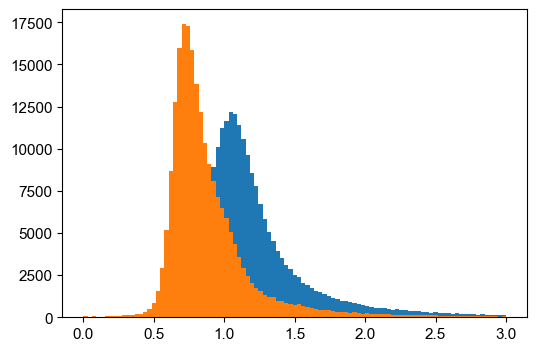

In [90]:
for skycolname in sky_adu_cols:
    print(skycolname)
    merged = merged_dict[skycolname]
    merged_snr_lynx = np.array(merged.snr_lynx)
    merged_snr_ztf =  np.array(merged.snr_ztf)
    idx = (~np.isnan(merged_snr_lynx)) & (~np.isnan(merged_snr_ztf))
    print("Valid data fraction:", np.sum(idx)/len(idx))
    diff = (merged_snr_lynx[idx] - merged_snr_ztf[idx])/merged_snr_ztf[idx]
    # difflow,diffhigh = np.percentile(diff[~np.isnan(diff)],[0.,100.])
    # plt.hist((merged_snr_lynx[idx] - merged_snr_ztf[idx])/merged_snr_ztf[idx],
    #          bins=np.linspace(difflow,diffhigh,100),alpha=0.2)
    print("snr frac difference median:",np.nanmedian(diff[(diff> difflow) & (diff <diffhigh)]))
    print("snr frac difference mean:",np.nanmean(diff[(diff> difflow) & (diff <diffhigh)]))
    p16, p84 = np.percentile(diff[(diff> difflow) & (diff <diffhigh)], [16, 84])
    print("snr frac difference scatter:",np.mean(p84-p16))
    print("snr diff max:",np.nanmax(diff))
    print("snr diff min:",np.nanmin(diff))

    ratio = merged_snr_lynx[idx]/merged_snr_ztf[idx]
    plt.hist(ratio,bins=np.linspace(0,3,100))

    print("snr ratio median:",np.nanmedian(ratio))
    print("snr ratio mean:",np.nanmean(ratio))
    p16, p84 = np.percentile(ratio, [16, 84])
    print("snr ratio scatter:",np.mean(p84-p16))
    print("snr ratio max:",np.nanmax(ratio))
    print("snr ratio min:",np.nanmin(ratio))

In [91]:
# for skycolname in sky_adu_cols:
#     lightcurves = lightcurves_dict[skycolname]
#     lightcurves.to_parquet(f'results/lightcurves_data_{skycolname}.parquet')